In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

In [2]:
df=pd.read_csv('ScreenTime_vs_MentalWellness.csv',index_col=None)
df

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
0,U0001,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3,NaN
1,U0002,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2,NaN
2,U0003,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6,NaN
3,U0004,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0,NaN
4,U0005,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,U0396,26,Female,Student,Remote,6.43,2.99,3.44,7.75,1,5.9,64.6,252,7.6,39.3,NaN
396,U0397,16,Male,Self-employed,Remote,9.59,5.44,4.15,5.57,1,10.0,47.4,99,7.0,3.5,NaN
397,U0398,40,Male,Student,Remote,8.72,2.36,6.36,7.56,1,9.4,57.3,193,10.1,6.6,NaN
398,U0399,29,Female,Retired,Hybrid,5.04,0.94,4.10,7.32,1,7.1,63.6,97,12.1,21.0,NaN


In [3]:
df = df.drop(['Unnamed: 15','user_id'],axis=1)
df

,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100
0,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3
1,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2
2,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6
3,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0
4,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,26,Female,Student,Remote,6.43,2.99,3.44,7.75,1,5.9,64.6,252,7.6,39.3
396,16,Male,Self-employed,Remote,9.59,5.44,4.15,5.57,1,10.0,47.4,99,7.0,3.5
397,40,Male,Student,Remote,8.72,2.36,6.36,7.56,1,9.4,57.3,193,10.1,6.6
398,29,Female,Retired,Hybrid,5.04,0.94,4.10,7.32,1,7.1,63.6,97,12.1,21.0


#1. Data Inspection
Check column names, data types, and value ranges
Understand what each feature represents
df.head()
df.info()
df.describe()
df.shape

In [4]:
df.head()

,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100
0,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3
1,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2
2,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6
3,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0
4,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          400 non-null    int64  
 1   gender                       400 non-null    object 
 2   occupation                   400 non-null    object 
 3   work_mode                    400 non-null    object 
 4   screen_time_hours            400 non-null    float64
 5   work_screen_hours            400 non-null    float64
 6   leisure_screen_hours         400 non-null    float64
 7   sleep_hours                  400 non-null    float64
 8   sleep_quality_1_5            400 non-null    int64  
 9   stress_level_0_10            400 non-null    float64
 10  productivity_0_100           400 non-null    float64
 11  exercise_minutes_per_week    400 non-null    int64  
 12  social_hours_per_week        400 non-null    float64
 13  mental_wellness_inde

In [6]:
df.shape

(400, 14)

In [7]:
df.describe()

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100
count,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,29.77750,9.024900,2.183075,6.841825,7.013175,1.397500,8.150500,54.306500,109.810000,7.905000,20.326750
std,7.46608,2.491058,1.931321,2.220896,0.852421,0.652348,2.094844,15.020054,70.007045,4.909632,20.376793
min,16.00000,1.000000,0.110000,0.890000,4.640000,1.000000,0.000000,20.600000,0.000000,0.000000,0.000000
25%,24.00000,7.372500,0.695000,5.460000,6.397500,1.000000,6.900000,43.600000,58.000000,4.575000,3.675000
50%,30.00000,9.090000,1.455000,6.700000,7.030000,1.000000,8.800000,51.750000,103.000000,7.750000,14.800000
75%,35.00000,10.495000,3.012500,8.417500,7.640000,2.000000,10.000000,63.000000,157.000000,11.025000,30.650000
max,60.00000,19.170000,12.040000,13.350000,9.740000,4.000000,10.000000,100.000000,372.000000,23.900000,97.000000


#2. Handling Missing Values
Removing null records
# Options:
df.dropna()                          # drop rows
df.fillna(df.mean())                 # fill with mean (numeric)
df.fillna(df.median())               # fill with median (skewed data)
df.fillna(df.mode().iloc[0])         # fill with mode (categorical)
df.isnull().sum()

In [8]:
df.isnull().sum()


age                            0
gender                         0
occupation                     0
work_mode                      0
screen_time_hours              0
work_screen_hours              0
leisure_screen_hours           0
sleep_hours                    0
sleep_quality_1_5              0
stress_level_0_10              0
productivity_0_100             0
exercise_minutes_per_week      0
social_hours_per_week          0
mental_wellness_index_0_100    0
dtype: int64

#3. Encoding Categorical Variables
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

# Binary (e.g., gender: Male/Female)
df['gender'] = LabelEncoder().fit_transform(df['gender'])

# Multi-class (e.g., platform: Instagram/TikTok/YouTube)
df = pd.get_dummies(df, columns=['platform'], drop_first=True)

In [9]:
#Check dtypes beforfitting the scaler
print(df.dtypes)


age                              int64
gender                          object
occupation                      object
work_mode                       object
screen_time_hours              float64
work_screen_hours              float64
leisure_screen_hours           float64
sleep_hours                    float64
sleep_quality_1_5                int64
stress_level_0_10              float64
productivity_0_100             float64
exercise_minutes_per_week        int64
social_hours_per_week          float64
mental_wellness_index_0_100    float64
dtype: object


In [10]:
df=pd.get_dummies(df,drop_first=True).astype(int)
df

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,gender_Male,gender_Non-binary/Other,occupation_Retired,occupation_Self-employed,occupation_Student,occupation_Unemployed,work_mode_In-person,work_mode_Remote
0,33,10,5,5,6,1,9,44,127,0,9,0,0,0,0,0,0,0,1
1,28,7,0,7,8,3,5,78,74,2,56,0,0,0,0,0,0,1,0
2,35,9,1,8,6,1,9,51,67,8,3,0,0,0,0,0,0,0,0
3,42,11,0,10,6,1,10,37,0,5,0,1,0,0,0,0,0,0,0
4,28,13,4,9,5,1,10,38,143,10,0,1,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,26,6,2,3,7,1,5,64,252,7,39,0,0,0,0,1,0,0,1
396,16,9,5,4,5,1,10,47,99,7,3,1,0,0,1,0,0,0,1
397,40,8,2,6,7,1,9,57,193,10,6,1,0,0,0,1,0,0,1
398,29,5,0,4,7,1,7,63,97,12,21,0,0,1,0,0,0,0,0


In [11]:
#4. Fix by converting the whole dataframe
df = df.apply(pd.to_numeric, errors='coerce')
df

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,gender_Male,gender_Non-binary/Other,occupation_Retired,occupation_Self-employed,occupation_Student,occupation_Unemployed,work_mode_In-person,work_mode_Remote
0,33,10,5,5,6,1,9,44,127,0,9,0,0,0,0,0,0,0,1
1,28,7,0,7,8,3,5,78,74,2,56,0,0,0,0,0,0,1,0
2,35,9,1,8,6,1,9,51,67,8,3,0,0,0,0,0,0,0,0
3,42,11,0,10,6,1,10,37,0,5,0,1,0,0,0,0,0,0,0
4,28,13,4,9,5,1,10,38,143,10,0,1,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,26,6,2,3,7,1,5,64,252,7,39,0,0,0,0,1,0,0,1
396,16,9,5,4,5,1,10,47,99,7,3,1,0,0,1,0,0,0,1
397,40,8,2,6,7,1,9,57,193,10,6,1,0,0,0,1,0,0,1
398,29,5,0,4,7,1,7,63,97,12,21,0,0,1,0,0,0,0,0


In [12]:
#5.Check dtypes before fitting the scaler
print(df.dtypes)


age                            int32
screen_time_hours              int32
work_screen_hours              int32
leisure_screen_hours           int32
sleep_hours                    int32
sleep_quality_1_5              int32
stress_level_0_10              int32
productivity_0_100             int32
exercise_minutes_per_week      int32
social_hours_per_week          int32
mental_wellness_index_0_100    int32
gender_Male                    int32
gender_Non-binary/Other        int32
occupation_Retired             int32
occupation_Self-employed       int32
occupation_Student             int32
occupation_Unemployed          int32
work_mode_In-person            int32
work_mode_Remote               int32
dtype: object


In [ ]:
#6. Outlier Detection & Removal

In [14]:

def quanQual(df):
    quan=[]
    qual=[]
    for columnName in df.columns:
        if(df[columnName].dtype=='O'):
             qual.append(columnName)
        else:
            quan.append(columnName)
    return quan,qual
        

In [15]:
quan,qual=quanQual(df)
quan


['age',
 'screen_time_hours',
 'work_screen_hours',
 'leisure_screen_hours',
 'sleep_hours',
 'sleep_quality_1_5',
 'stress_level_0_10',
 'productivity_0_100',
 'exercise_minutes_per_week',
 'social_hours_per_week',
 'mental_wellness_index_0_100',
 'gender_Male',
 'gender_Non-binary/Other',
 'occupation_Retired',
 'occupation_Self-employed',
 'occupation_Student',
 'occupation_Unemployed',
 'work_mode_In-person',
 'work_mode_Remote']

In [16]:
qual

[]

In [17]:
descriptive=pd.DataFrame(index=["Mean","Median","Mode","Q1:25%","Q2:50%","Q3:75%","Q4:100%","IQR","1.5rule","Lesser","Greater","Min","Max"],columns=quan)
for columnName in quan:
    descriptive[columnName]["Mean"]=df[columnName].mean()
    descriptive[columnName]["Median"]=df[columnName].median()
    descriptive[columnName]["Mode"]=df[columnName].mode()[0]
    descriptive[columnName]["Q1:25%"]=df.describe()[columnName]["25%"]
    descriptive[columnName]["Q2:50%"]=df.describe()[columnName]["50%"]
    descriptive[columnName]["Q3:75%"]=df.describe()[columnName]["75%"]
    descriptive[columnName]["Q4:100%"]=df.describe()[columnName]["max"]
    descriptive[columnName]["IQR"]=descriptive[columnName]["Q3:75%"]-descriptive[columnName]["Q1:25%"]
    descriptive[columnName]["1.5rule"]=1.5*descriptive[columnName]["IQR"]
    descriptive[columnName]["Lesser"]=descriptive[columnName]["Q1:25%"]-descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Greater"]=descriptive[columnName]["Q3:75%"]+descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Min"]=df[columnName].min()
    descriptive[columnName]["Max"]=df[columnName].max()
descriptive

C:\Users\KP\AppData\Local\Temp\ipykernel_6468\1077176783.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  descriptive[columnName]["Mean"]=df[columnName].mean()
C:\Users\KP\AppData\Local\Temp\ipykernel_6468\1077176783.py:4: FutureWarning: 

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,gender_Male,gender_Non-binary/Other,occupation_Retired,occupation_Self-employed,occupation_Student,occupation_Unemployed,work_mode_In-person,work_mode_Remote
Mean,29.7775,8.5575,1.655,6.36,6.5225,1.3975,7.8475,53.8725,109.81,7.5075,19.9475,0.425,0.02,0.035,0.1125,0.2675,0.0675,0.26,0.375
Median,30.0,9.0,1.0,6.0,7.0,1.0,8.0,51.0,103.0,7.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Mode,32,9,0,6,7,1,10,49,0,0,0,0,0,0,0,0,0,0,0
Q1:25%,24.0,7.0,0.0,5.0,6.0,1.0,6.0,43.0,58.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Q2:50%,30.0,9.0,1.0,6.0,7.0,1.0,8.0,51.0,103.0,7.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Q3:75%,35.0,10.0,3.0,8.0,7.0,2.0,10.0,63.0,157.0,11.0,30.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
Q4:100%,60.0,19.0,12.0,13.0,9.0,4.0,10.0,100.0,372.0,23.0,97.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
IQR,11.0,3.0,3.0,3.0,1.0,1.0,4.0,20.0,99.0,7.0,27.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
1.5rule,16.5,4.5,4.5,4.5,1.5,1.5,6.0,30.0,148.5,10.5,40.5,1.5,0.0,0.0,0.0,1.5,0.0,1.5,1.5
Lesser,7.5,2.5,-4.5,0.5,4.5,-0.5,0.0,13.0,-90.5,-6.5,-37.5,-1.5,0.0,0.0,0.0,-1.5,0.0,-1.5,-1.5


In [18]:
lesser=[]
greater=[]
for columnName in quan:
    if(descriptive[columnName]["Min"]<descriptive[columnName]["Lesser"]):
        lesser.append(columnName)
    if(descriptive[columnName]["Max"]>descriptive[columnName]["Greater"]):
       greater.append(columnName)

In [19]:
lesser

['screen_time_hours', 'leisure_screen_hours', 'sleep_hours']

In [20]:
greater

['age',
 'screen_time_hours',
 'work_screen_hours',
 'leisure_screen_hours',
 'sleep_hours',
 'sleep_quality_1_5',
 'productivity_0_100',
 'exercise_minutes_per_week',
 'social_hours_per_week',
 'mental_wellness_index_0_100',
 'gender_Non-binary/Other',
 'occupation_Retired',
 'occupation_Self-employed',
 'occupation_Unemployed']

In [21]:
for columnName in lesser:
    df[columnName][df[columnName]<descriptive[columnName]["Lesser"]]=descriptive[columnName]["Lesser"]
for columnName in greater:
    df[columnName][df[columnName]>descriptive[columnName]["Greater"]]=descriptive[columnName]["Greater"]

C:\Users\KP\AppData\Local\Temp\ipykernel_6468\752010338.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[columnName][df[columnName]<descriptive[columnName]["Lesser"]]=descriptive[columnName]["Lesser"]
C:\Users\KP\AppData\Local\Temp\ipy

In [22]:
descriptive=pd.DataFrame(index=["Mean","Median","Mode","Q1:25%","Q2:50%","Q3:75%","Q4:100%","IQR","1.5rule","Lesser","Greater","Min","Max"],columns=quan)
for columnName in quan:
    descriptive[columnName]["Mean"]=df[columnName].mean()
    descriptive[columnName]["Median"]=df[columnName].median()
    descriptive[columnName]["Mode"]=df[columnName].mode()[0]
    descriptive[columnName]["Q1:25%"]=df.describe()[columnName]["25%"]
    descriptive[columnName]["Q2:50%"]=df.describe()[columnName]["50%"]
    descriptive[columnName]["Q3:75%"]=df.describe()[columnName]["75%"]
    descriptive[columnName]["Q4:100%"]=df.describe()[columnName]["max"]
    descriptive[columnName]["IQR"]=descriptive[columnName]["Q3:75%"]-descriptive[columnName]["Q1:25%"]
    descriptive[columnName]["1.5rule"]=1.5*descriptive[columnName]["IQR"]
    descriptive[columnName]["Lesser"]=descriptive[columnName]["Q1:25%"]-descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Greater"]=descriptive[columnName]["Q3:75%"]+descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Min"]=df[columnName].min()
    descriptive[columnName]["Max"]=df[columnName].max()
descriptive

C:\Users\KP\AppData\Local\Temp\ipykernel_6468\1077176783.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  descriptive[columnName]["Mean"]=df[columnName].mean()
C:\Users\KP\AppData\Local\Temp\ipykernel_6468\1077176783.py:4: FutureWarning: 

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,gender_Male,gender_Non-binary/Other,occupation_Retired,occupation_Self-employed,occupation_Student,occupation_Unemployed,work_mode_In-person,work_mode_Remote
Mean,29.75625,8.5475,1.64375,6.35875,6.52,1.39375,7.8475,53.7775,109.64375,7.50375,19.615,0.425,0.0,0.0,0.0,0.2675,0.0,0.26,0.375
Median,30.0,9.0,1.0,6.0,7.0,1.0,8.0,51.0,103.0,7.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Mode,32.0,9.0,0.0,6.0,7.0,1.0,10,49,0.0,0.0,0.0,0,0,0,0,0,0,0,0
Q1:25%,24.0,7.0,0.0,5.0,6.0,1.0,6.0,43.0,58.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Q2:50%,30.0,9.0,1.0,6.0,7.0,1.0,8.0,51.0,103.0,7.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Q3:75%,35.0,10.0,3.0,8.0,7.0,2.0,10.0,63.0,157.0,11.0,30.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
Q4:100%,51.5,14.5,7.5,12.5,8.5,3.5,10.0,93.0,305.5,21.5,70.5,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
IQR,11.0,3.0,3.0,3.0,1.0,1.0,4.0,20.0,99.0,7.0,27.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
1.5rule,16.5,4.5,4.5,4.5,1.5,1.5,6.0,30.0,148.5,10.5,40.5,1.5,0.0,0.0,0.0,1.5,0.0,1.5,1.5
Lesser,7.5,2.5,-4.5,0.5,4.5,-0.5,0.0,13.0,-90.5,-6.5,-37.5,-1.5,0.0,0.0,0.0,-1.5,0.0,-1.5,-1.5


In [23]:
lesser=[]
greater=[]
for columnName in quan:
    if(descriptive[columnName]["Min"]<descriptive[columnName]["Lesser"]):
        lesser.append(columnName)
    if(descriptive[columnName]["Max"]>descriptive[columnName]["Greater"]):
       greater.append(columnName)

In [24]:
lesser

[]

In [25]:
greater

[]

In [26]:
df_preprocessed = df.copy()
df_preprocessed

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,gender_Male,gender_Non-binary/Other,occupation_Retired,occupation_Self-employed,occupation_Student,occupation_Unemployed,work_mode_In-person,work_mode_Remote
0,33.0,10.0,5.0,5.0,6.0,1.0,9,44,127.0,0.0,9.0,0,0,0,0,0,0,0,1
1,28.0,7.0,0.0,7.0,8.0,3.0,5,78,74.0,2.0,56.0,0,0,0,0,0,0,1,0
2,35.0,9.0,1.0,8.0,6.0,1.0,9,51,67.0,8.0,3.0,0,0,0,0,0,0,0,0
3,42.0,11.0,0.0,10.0,6.0,1.0,10,37,0.0,5.0,0.0,1,0,0,0,0,0,0,0
4,28.0,13.0,4.0,9.0,5.0,1.0,10,38,143.0,10.0,0.0,1,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,26.0,6.0,2.0,3.0,7.0,1.0,5,64,252.0,7.0,39.0,0,0,0,0,1,0,0,1
396,16.0,9.0,5.0,4.0,5.0,1.0,10,47,99.0,7.0,3.0,1,0,0,0,0,0,0,1
397,40.0,8.0,2.0,6.0,7.0,1.0,9,57,193.0,10.0,6.0,1,0,0,0,1,0,0,1
398,29.0,5.0,0.0,4.0,7.0,1.0,7,63,97.0,12.0,21.0,0,0,0,0,0,0,0,0


In [27]:
df_preprocessed.to_csv('preprocessed_data.csv', index=False)
print('Saved as df_preprocessed!')

Saved as df_preprocessed!


#1. Distribution Plots
Understand spread, skewness of screen time, stress, sleep

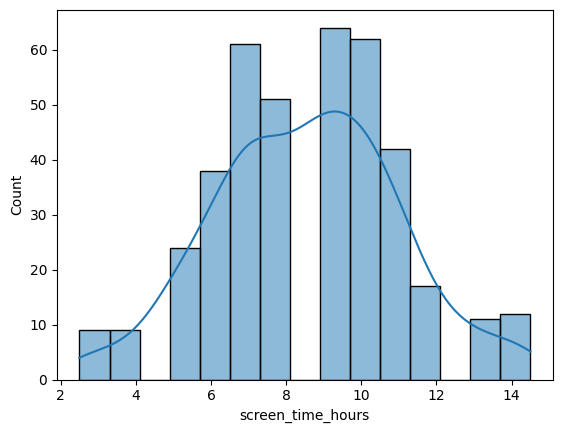

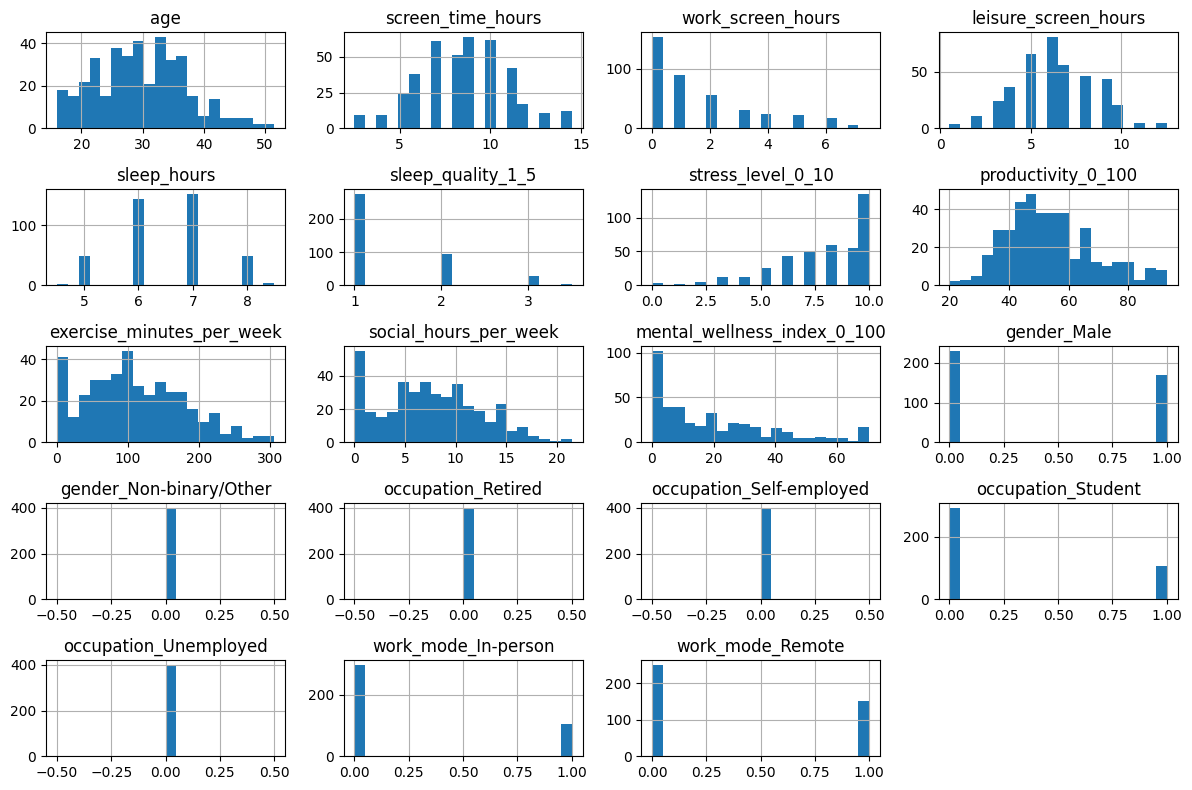

In [28]:
# Histogram — distribution of screen time
#A histogram shows how many times each value appears in a column
sns.histplot(df['screen_time_hours'], kde=True)

# For all numeric features at once
df.hist(figsize=(12, 8), bins=20)
plt.tight_layout()

2. Correlation Heatmap
See which features are most related to mental wellness
Key insight: does more screen time = higher stress?

In [ ]:
selected_columns = df[['screen_time_hours', 'mental_wellness_index_0_100', 
                        'stress_level_0_10', 'sleep_quality_1_5']]

plt.figure(figsize=(8, 6))
sns.heatmap(selected_columns.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Selected Features')
plt.show()

<Axes: xlabel='screen_time_hours', ylabel='mental_wellness_index_0_100'>

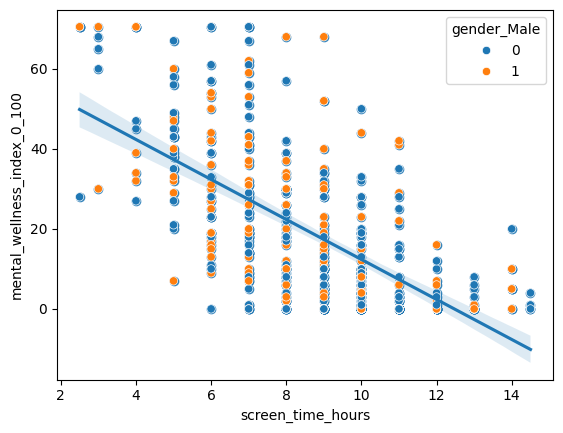

In [29]:
#3. Scatter Plots
# Screen time vs Mental wellness
sns.scatterplot(x='screen_time_hours', y='mental_wellness_index_0_100', data=df)

# With regression line
sns.regplot(x='screen_time_hours', y='mental_wellness_index_0_100', data=df)

# Colored by gender
sns.scatterplot(x='screen_time_hours', y='mental_wellness_index_0_100',hue='gender_Male', data=df)

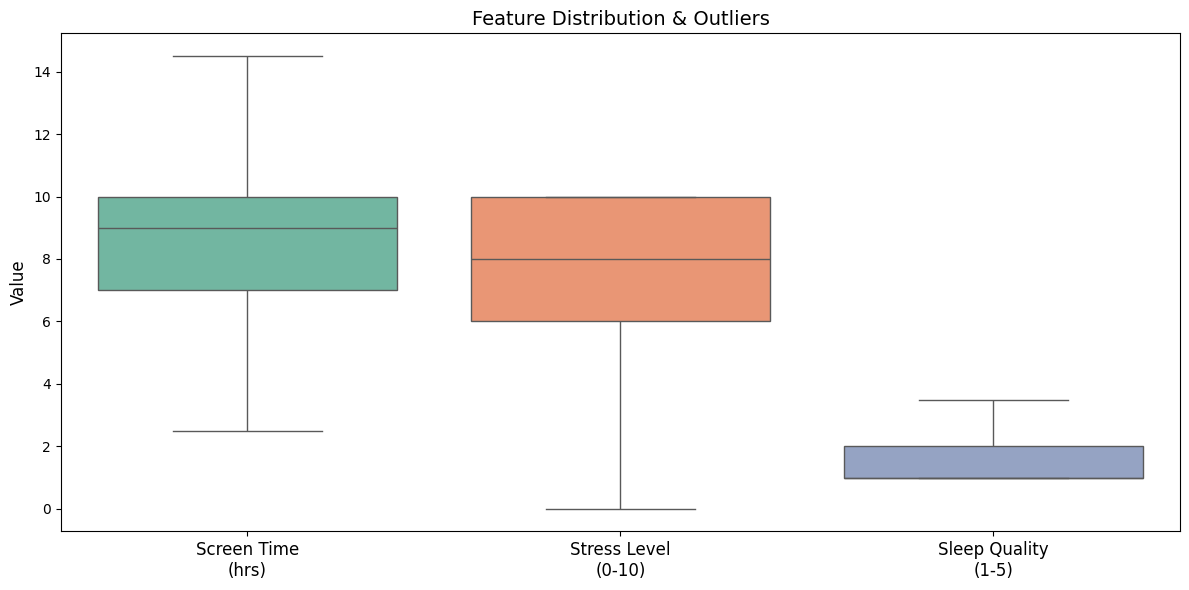

In [30]:
#4. Box Plots
#Great for comparing groups and spotting outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['screen_time_hours', 'stress_level_0_10', 'sleep_quality_1_5']],
            palette='Set2')   # adds color

plt.xticks(ticks=[0, 1, 2],
           labels=['Screen Time\n(hrs)', 'Stress Level\n(0-10)', 'Sleep Quality\n(1-5)'],
           fontsize=12)        # \n adds a new line in label

plt.title('Feature Distribution & Outliers', fontsize=14)
plt.ylabel('Value', fontsize=12)
plt.tight_layout()
plt.show()

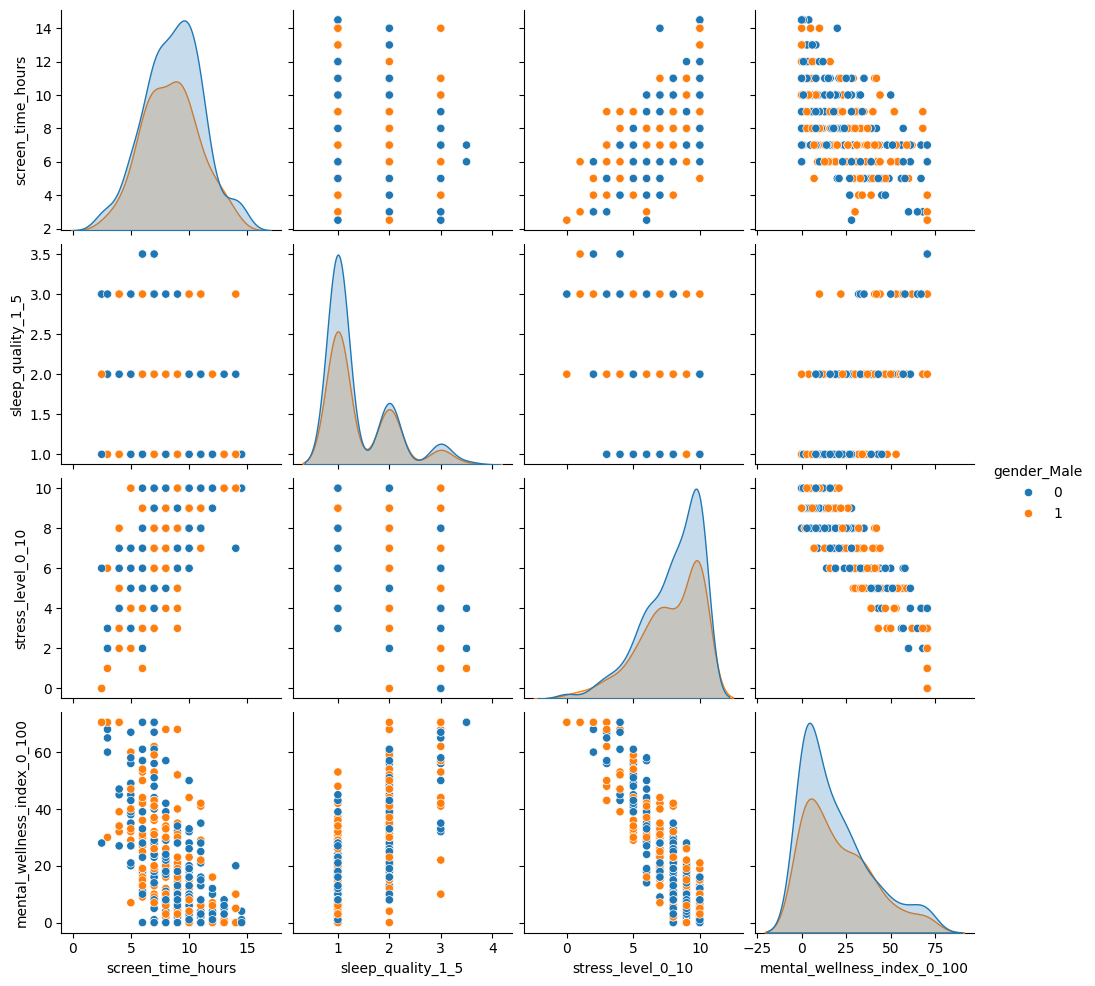

In [31]:
#5. Pair Plot
#See all feature relationships in one shot
#Color by gender to find group differences
sns.pairplot(df[['screen_time_hours', 'sleep_quality_1_5', 
                  'stress_level_0_10', 'mental_wellness_index_0_100','gender_Male']], 
             hue='gender_Male')

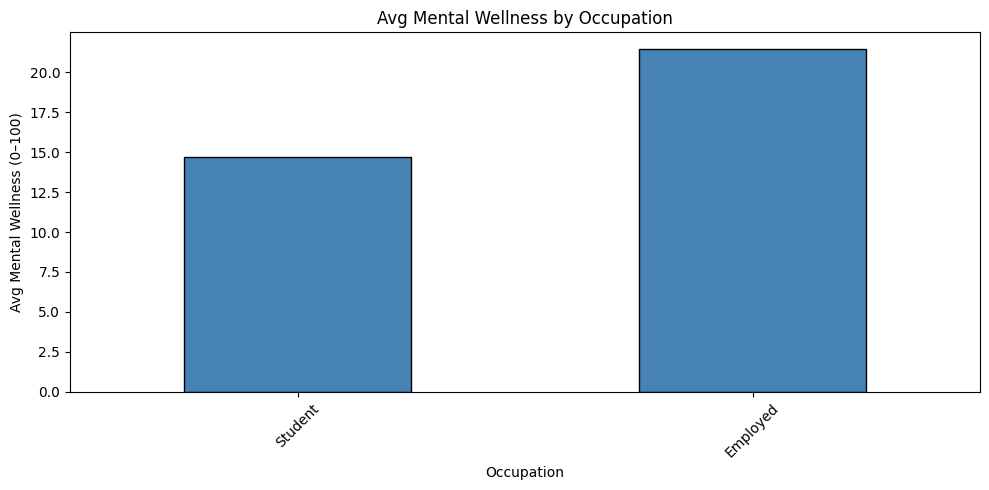

In [37]:
#6. Bar Plots
#Compare wellness scores across platform
# Average mental wellness by platform
# One-hot encoded occupation columns
occ_cols = ['occupation_Retired', 'occupation_Self-employed', 
            'occupation_Student', 'occupation_Unemployed']

def get_occupation(row):
    for col in occ_cols:
        if row[col] == 1:
            return col.replace('occupation_', '')
    return 'Employed'  # baseline (all four cols = 0)

df['occupation'] = df.apply(get_occupation, axis=1)

plt.figure(figsize=(10, 5))
df.groupby('occupation')['mental_wellness_index_0_100'].mean() \
  .sort_values() \
  .plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Avg Mental Wellness by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Avg Mental Wellness (0–100)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Axes: xlabel='screen_time_hours', ylabel='stress_level_0_10'>

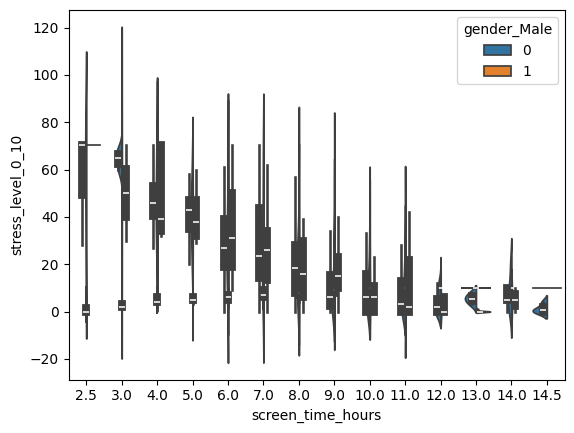

In [45]:
#7. Violin Plot
#Richer than box plots — shows full distribution shape
# Distribution + box plot combined
sns.violinplot(x='screen_time_hours', y='stress_level_0_10', data=df)

# Split by gender
sns.violinplot(x='screen_time_hours', y='mental_wellness_index_0_100', 
               hue='gender_Male', split=True, data=df)


C:\Users\KP\anaconda3\envs\aiml\Lib\site-packages\seaborn\categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)


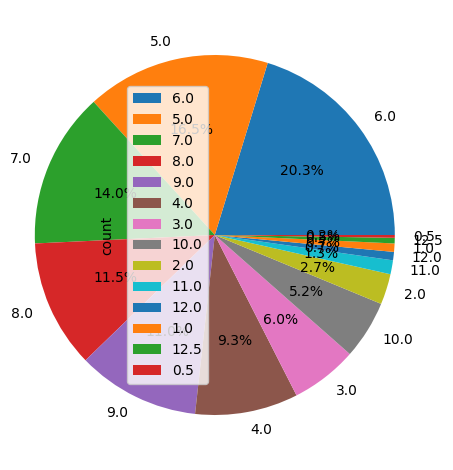

In [51]:
#8. Pie / Count Plot
#Understand dataset composition
# Platform usage distribution
df['leisure_screen_hours'].value_counts().plot(kind='pie', autopct='%1.1f%%')

#  distribution
sns.countplot(x='work_mode_Remote', data=df)
plt.tight_layout()